In [1]:
PP[u_, v_, Q_] := u^2((1-u)(u^2+A^2)-Q*u*v);
QQ[u_, v_, B_] := B(u-v)(u^2+A^2)v;

q = (1 - H)(A^2 + H^2)/H^2;
b = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
$Assumptions = {H < 1/2, A^2 < H^2(1 - 2H), A ∈ Reals, H ∈ Reals};

2    2
       2                2          2    (1 - H) (A  + H ) (H + u) (H + v)
(H + u)  ((1 - H - u) (A  + (H + u) ) - ---------------------------------)
                                                        2
                                                       H
   2              2    2          2
(-A  + (1 - 2 H) H ) (A  + (H + u) ) (u - v) (H + v)
----------------------------------------------------
                       2    2
                      A  + H
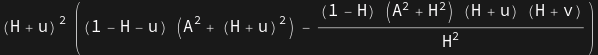
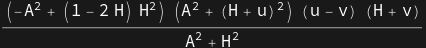

In [6]:
P1[u_, v_] = PP[u + H, v + H, q]
Q1[u_, v_] = QQ[u + H, v + H, b]

In [8]:
jac = {{FullSimplify[D[P1[u, v], u]], FullSimplify[D[P1[u, v], v]]}, {FullSimplify[D[Q1[u, v], u]], FullSimplify[D[Q1[u, v], v]]}} /. {u -> 0, v -> 0}

2       2          2                2    2
{{-(A  H) - H  (-H + 2 H ), (-1 + H) H (A  + H )}, 
 
           2    2                   2    2
>   {-(H (A  + H  (-1 + 2 H))), H (A  + H  (-1 + 2 H))}}

In [9]:
detY[B_] = B H^2(A^2 + H^2)(H^3 + A^2(2 − H));
detJ = FullSimplify[Det[jac]]
Simplify[detY[b] - detJ]
Simplify[Tr[jac]]

2     2              3    2    2
-(H  (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H)))
0
0

In [21]:
A = 0.1; H = 0.4;
detJ
Clear[A, H]

0.0002816

4    4        2  2      2  3      2  4    5      6
{{-(H Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]), 
 
               4    4        2  2      2  3      2  4    5      6
>    H Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]}, 
 
          2    2      3           4    4        2  2      2  3      2  4    5      6
        -A  + H  - 2 H  - Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]
>   {{-(-----------------------------------------------------------------------------), 
                                        2    2      3
                                       A  - H  + 2 H
 
>     1}, {-(
 
           2    2      3           4    4        2  2      2  3      2  4    5      6
         -A  + H  - 2 H  + Sqrt[2 A  - A  H - 2 A  H  + 6 A  H  - 2 A  H  - H  + 2 H ]
>        -----------------------------------------------------------------------------), 
                                         2    2      3
                                        A  - H  + 2 H
 
>     1}}}
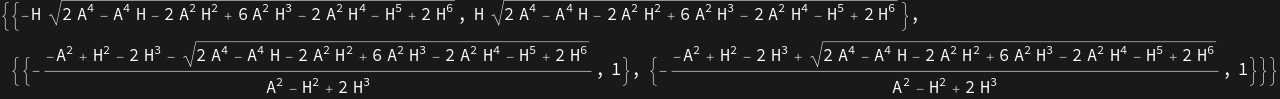

In [13]:
{vals, vecs} = Eigensystem[jac]

2              3
          -(A  (-2 + H)) + H
{1 + Sqrt[-------------------], 1}
           2    2
          A  + H  (-1 + 2 H)
           2             3    2    2
H Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
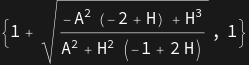

In [19]:
v2 = FullSimplify[vecs[[2]]]
omega = FullSimplify[vals[[2]]]

In [16]:
A = 0.1; H = 0.4;
vecs[[2]]
Clear[A, H]

{1. + 1.90693 I, 1}

2             3
   A  (-2 + H) - H
{{------------------, 1}, {0, 1}}
   2    2
  A  + H  (-1 + 2 H)
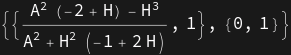

In [57]:
imv2 = {(A^2 (-2 + H) - H^3)/(A^2 + H^2 (-1 + 2H)), 0};
rev2 = {1, 1};
P = Transpose[{imv2, rev2}]